# Part D1: Controlled Stress Tests

Stress-testing the basic Tomasi-Kanade factorization over noise, missing data, and geometric degeneracy.
We use a naive NaN-handling baseline (nanmean centering + zero-fill) to reveal where the method breaks down,
motivating proper matrix completion in Part D2.

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import generate_sfm_data
from src.factorization import factorize_tomasi_kanade, center_data
from src.utils import reprojection_rmse, procrustes_align

## 1. Stress-Test Configuration

In [90]:
noise_levels = [0.0, 0.02, 0.04, 0.06, 0.08]

missing_rates = [0.0, 0.05, 0.1, 0.15, 0.2]
degeneracy_configs = [
    ("full_3d", "diverse"),
    ("near_planar", "diverse"),
]
NUM_POINTS = 50
NUM_FRAMES = 10
NUM_RUNS = 100
DEGENERACY_LABELS = {"full_3d": "Fully 3D", "near_planar": "Near Planar"}

print(f"Grid: {len(noise_levels)} noise x {len(missing_rates)} missing x {len(degeneracy_configs)} degeneracy")
print(f"Total conditions: {len(noise_levels) * len(missing_rates) * len(degeneracy_configs)}")
print(f"Runs per condition: {NUM_RUNS}")

Grid: 5 noise x 5 missing x 2 degeneracy
Total conditions: 50
Runs per condition: 100


## Visualizing Noise

Before running the full stress-test grid, let's see what additive Gaussian noise looks like on the 2D measurements.
For a single frame, we plot the clean projected points alongside the noisy ones, with arrows showing each point's displacement.

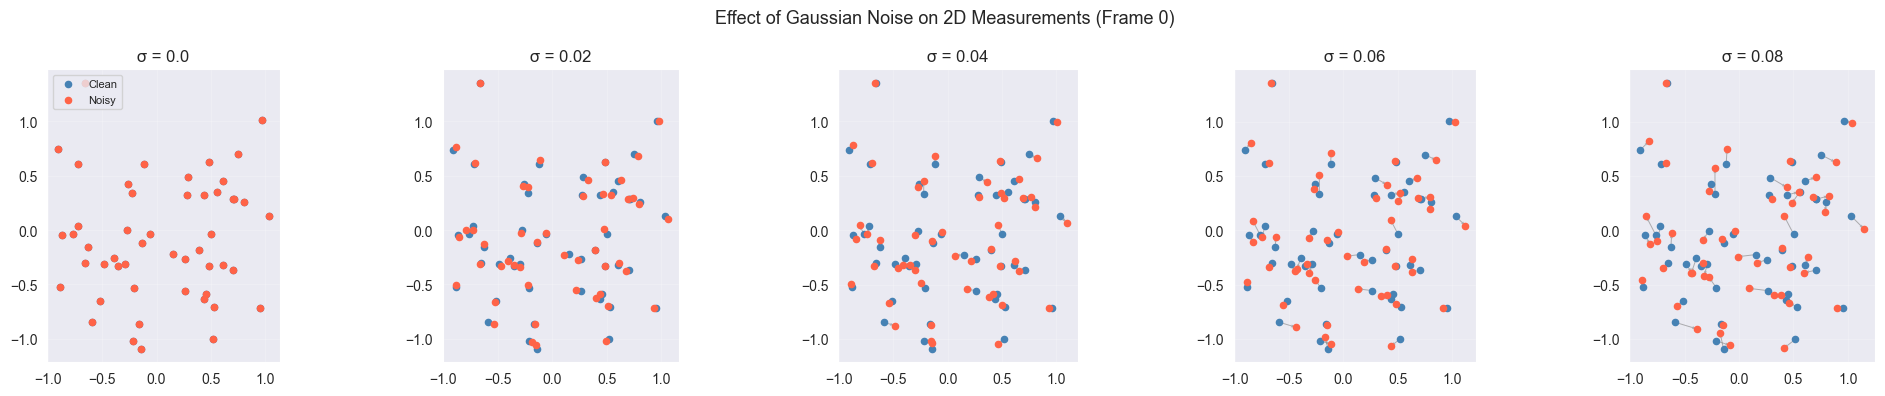

In [91]:
# Generate clean baseline (frame 0)
clean_data = generate_sfm_data(
    num_points=NUM_POINTS, num_frames=NUM_FRAMES, sigma=0.0, seed=42
)
u_clean = clean_data["measurement_matrix_clean"][0, :]  # x-coords, frame 0
v_clean = clean_data["measurement_matrix_clean"][1, :]  # y-coords, frame 0

fig, axes = plt.subplots(1, len(noise_levels), figsize=(4 * len(noise_levels), 4))

for ax, sigma in zip(axes, noise_levels):
    noisy_data = generate_sfm_data(
        num_points=NUM_POINTS, num_frames=NUM_FRAMES, sigma=sigma, seed=42
    )
    u_noisy = noisy_data["measurement_matrix"][0, :]
    v_noisy = noisy_data["measurement_matrix"][1, :]

    du = u_noisy - u_clean
    dv = v_noisy - v_clean

    ax.scatter(u_clean, v_clean, s=20, c="steelblue", zorder=3, label="Clean")
    ax.scatter(u_noisy, v_noisy, s=20, c="tomato", zorder=3, label="Noisy")
    ax.quiver(
        u_clean, v_clean, du, dv,
        angles="xy", scale_units="xy", scale=1,
        color="gray", alpha=0.6, width=0.004,
    )
    ax.set_title(f"σ = {sigma}")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)
    if ax is axes[0]:
        ax.legend(fontsize=8, loc="upper left")

fig.suptitle("Effect of Gaussian Noise on 2D Measurements (Frame 0)", fontsize=13)
fig.tight_layout()
plt.show()

## 2. Run Stress Tests

In [92]:
# Results keyed by (point_shape, motion_type)
# Each value: dict with 'rmse' (5x5 averaged array) and 'singular_values' (5x5x6 averaged array)
results = {}

for point_shape, motion_type in degeneracy_configs:
    n_noise = len(noise_levels)
    n_miss = len(missing_rates)
    rmse_accum = np.zeros((NUM_RUNS, n_noise, n_miss))
    sv_accum = np.zeros((NUM_RUNS, n_noise, n_miss, 6))

    for run in range(NUM_RUNS):
        for i, sigma in enumerate(noise_levels):
            for j, miss in enumerate(missing_rates):
                data = generate_sfm_data(
                    num_points=NUM_POINTS,
                    num_frames=NUM_FRAMES,
                    sigma=sigma,
                    missing_rate=miss,
                    point_shape=point_shape,
                    degeneracy_motion=motion_type,
                    seed=run,
                )
                W = data["measurement_matrix"]

                motion, structure, trans = factorize_tomasi_kanade(W)

                # Reprojection RMSE (observed entries only)
                rmse_accum[run, i, j] = reprojection_rmse(W, motion, structure, trans)

                # Singular values of centered matrix (for analysis)
                centered = W.copy()
                num_frames = W.shape[0] // 2
                for f in range(num_frames):
                    centered[2 * f] -= np.nanmean(centered[2 * f])
                    centered[2 * f + 1] -= np.nanmean(centered[2 * f + 1])
                np.nan_to_num(centered, copy=False, nan=0.0)
                sv = np.linalg.svd(centered, compute_uv=False)
                sv_accum[run, i, j] = sv[:6]

    results[(point_shape, motion_type)] = {
        "rmse": rmse_accum.mean(axis=0),
        "singular_values": sv_accum.mean(axis=0),
    }
print("All conditions computed (averaged over {} runs).".format(NUM_RUNS))

All conditions computed (averaged over 100 runs).


## 3. Reprojection Error Heatmaps

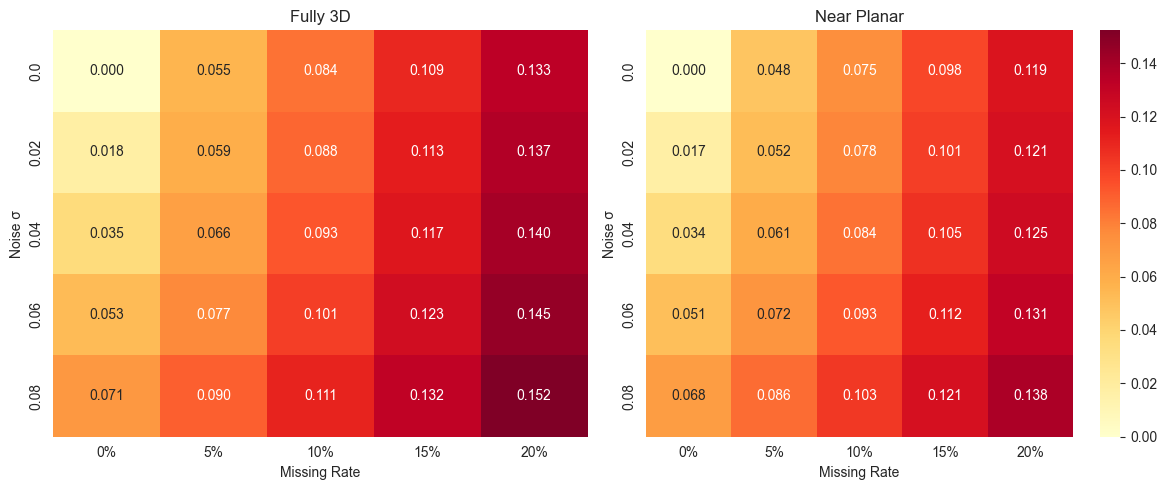

In [93]:
# Find global min/max for shared color scale
all_rmse = np.array([results[k]["rmse"] for k in results])
vmin = all_rmse.min()
vmax = all_rmse.max()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

noise_labels = [str(s) for s in noise_levels]
miss_labels = [f"{int(m*100)}%" for m in missing_rates]

for idx, (point_shape, motion_type) in enumerate(degeneracy_configs):
    ax = axes[idx]
    rmse = results[(point_shape, motion_type)]["rmse"]

    sns.heatmap(
        rmse,
        ax=ax,
        annot=True,
        fmt=".3f",
        xticklabels=miss_labels,
        yticklabels=noise_labels,
        vmin=vmin,
        vmax=vmax,
        cmap="YlOrRd",
        cbar=idx == 1,
    )
    ax.set_title(DEGENERACY_LABELS[point_shape])
    ax.set_xlabel("Missing Rate")
    ax.set_ylabel("Noise σ")

fig.tight_layout()
plt.show()

## 4. Singular Value Analysis

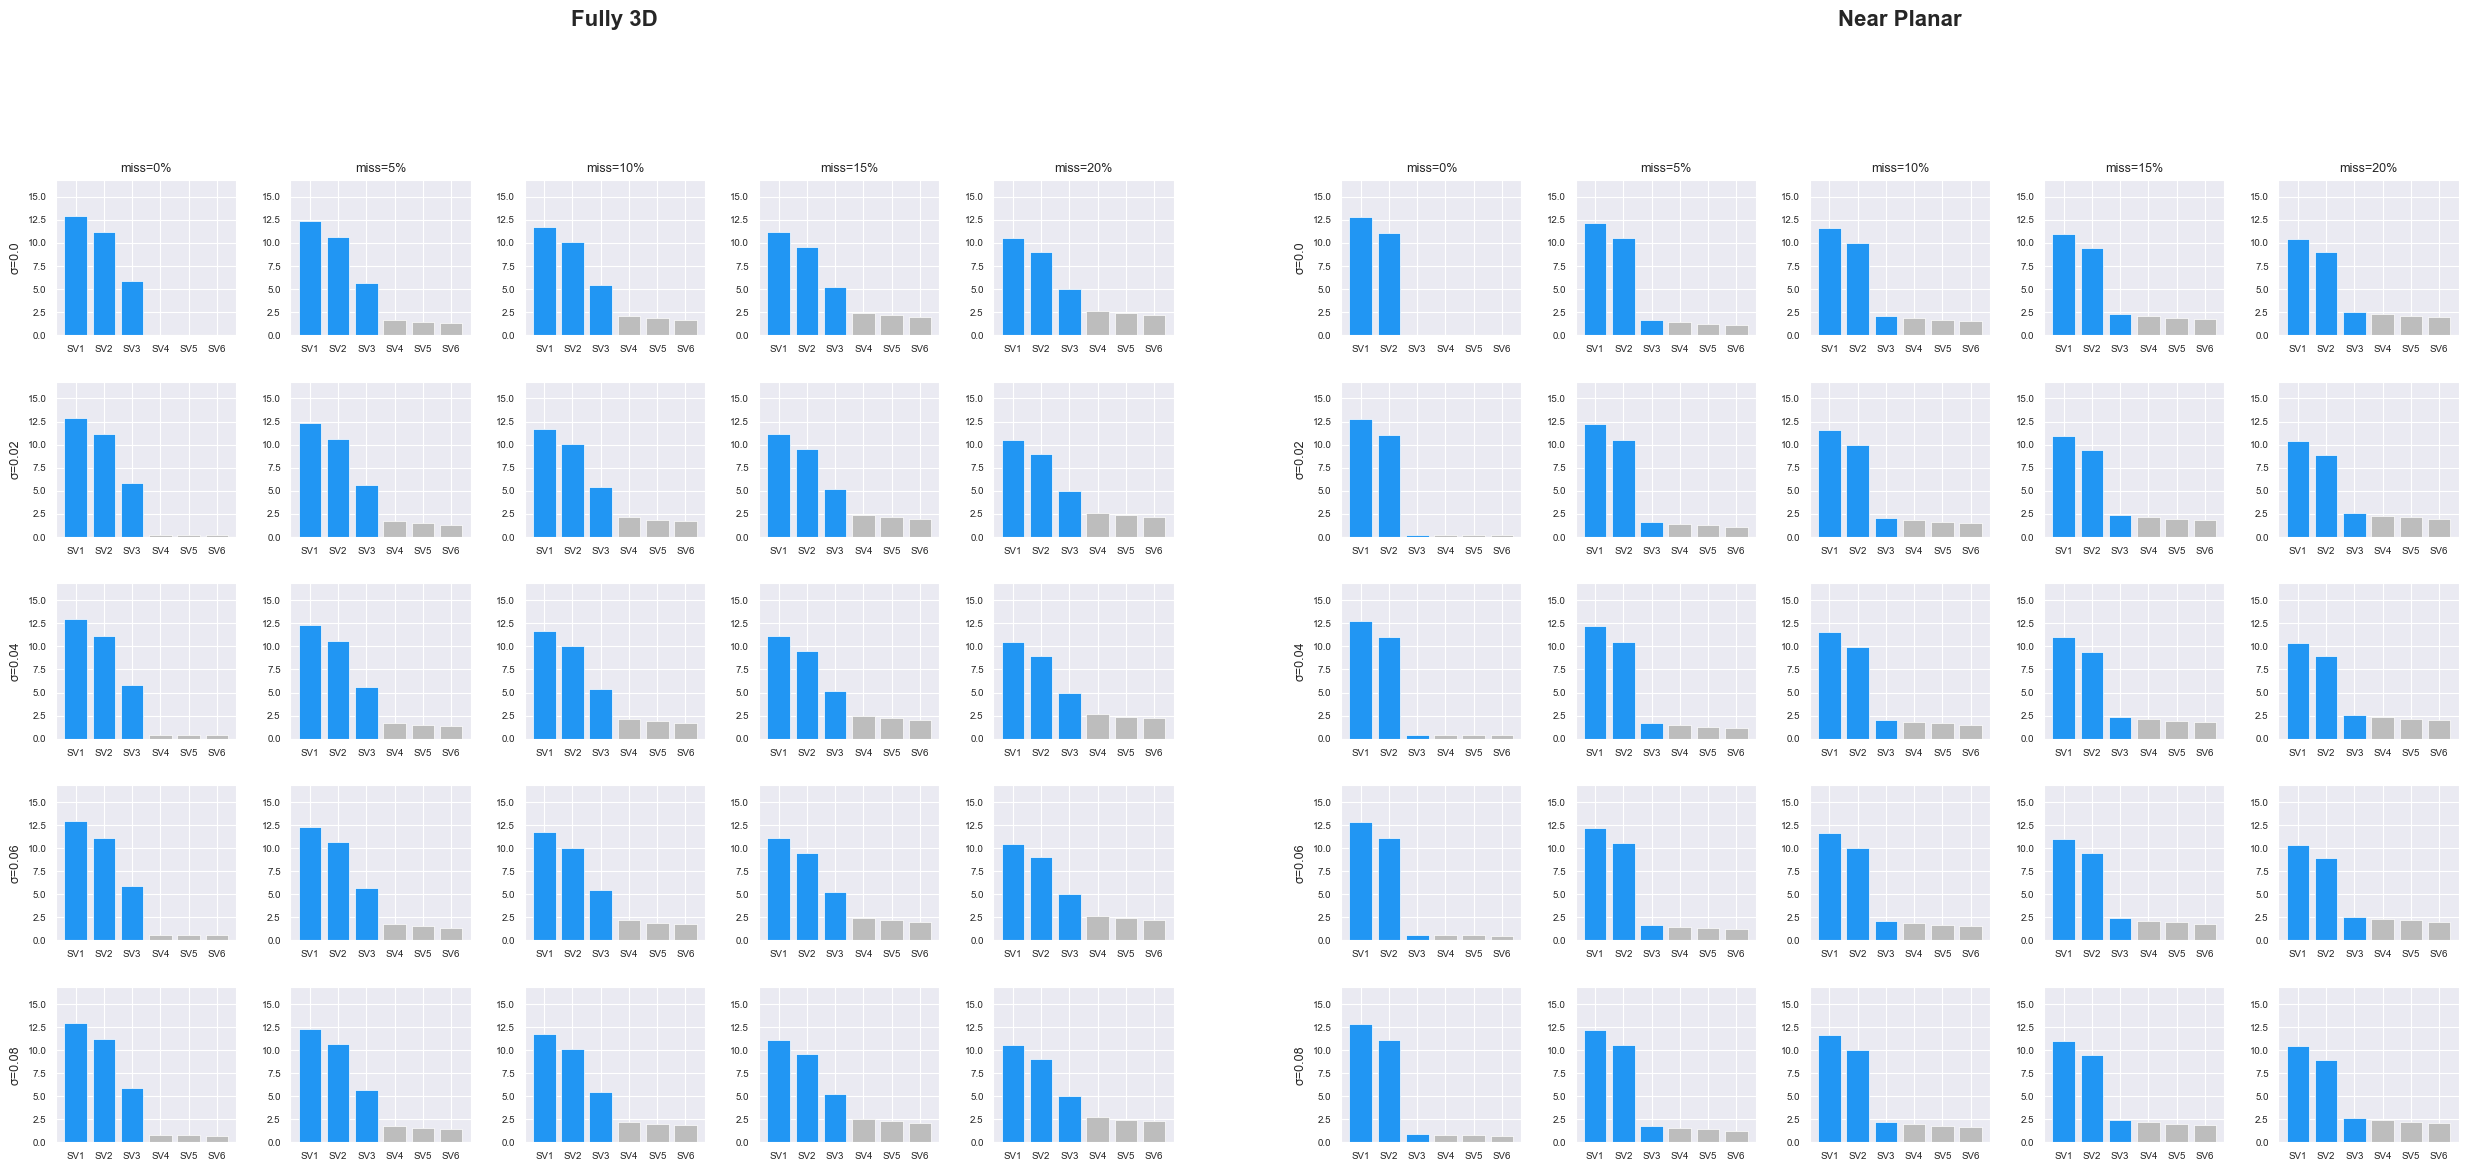

In [94]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

n_noise = len(noise_levels)
n_miss = len(missing_rates)

# Global ymax across BOTH configs for a shared y-axis
all_svs = []
for point_shape, motion_type in degeneracy_configs:
    sv_grid = results[(point_shape, motion_type)]["singular_values"]
    all_svs += [sv_grid[i, j] for i in range(n_noise) for j in range(n_miss)]
ymax = max(sv.max() for sv in all_svs) * 1.3

fig = plt.figure(figsize=(3 * n_miss * 2 + 1, 2.5 * n_noise))
outer = GridSpec(1, 2, figure=fig, wspace=0.15)

# Create all axes, sharing x/y with the very first axis across both blocks
anchor_ax = None
axes_blocks = []
for cfg_idx in range(2):
    inner = GridSpecFromSubplotSpec(n_noise, n_miss, subplot_spec=outer[cfg_idx],
                                    hspace=0.3, wspace=0.3)
    block = np.empty((n_noise, n_miss), dtype=object)
    for i in range(n_noise):
        for j in range(n_miss):
            kw = {}
            if anchor_ax is not None:
                kw = dict(sharey=anchor_ax, sharex=anchor_ax)
            ax = fig.add_subplot(inner[i, j], **kw)
            if anchor_ax is None:
                anchor_ax = ax
            block[i, j] = ax
    axes_blocks.append(block)

for cfg_idx, (point_shape, motion_type) in enumerate(degeneracy_configs):
    sv_grid = results[(point_shape, motion_type)]["singular_values"]
    block = axes_blocks[cfg_idx]

    for i in range(n_noise):
        for j in range(n_miss):
            ax = block[i, j]
            sv = sv_grid[i, j]

            colors = ["#2196F3"] * 3 + ["#BDBDBD"] * 3
            ax.bar(range(1, 7), sv, color=colors, edgecolor="white", linewidth=0.5)
            ax.set_ylim(bottom=0, top=ymax)
            ax.tick_params(labelsize=7)

            if i == 0:
                ax.set_title(f"miss={int(missing_rates[j]*100)}%", fontsize=9)
            if j == 0:
                ax.set_ylabel(f"σ={noise_levels[i]}", fontsize=9)
            if i == n_noise - 1:
                ax.set_xticks(range(1, 7))
                ax.set_xticklabels([f"SV{k}" for k in range(1, 7)], fontsize=7)

# Group titles above each block
for cfg_idx, (point_shape, motion_type) in enumerate(degeneracy_configs):
    block = axes_blocks[cfg_idx]
    left = block[0, 0].get_position().x0
    right = block[0, n_miss - 1].get_position().x1
    cx = (left + right) / 2
    fig.text(cx, 1.0, DEGENERACY_LABELS[point_shape],
             ha="center", va="bottom", fontsize=16, fontweight="bold")

plt.show()